Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [1]:
import random
random.seed(1234)

In [2]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

2026-03-19 15:47:44.147041: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 15:47:44.607656: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773931669.161160    1452 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


2026-03-19 15:47:49.510995: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-03-19 15:47:49.527548: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

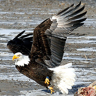
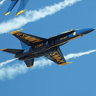
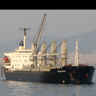
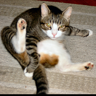

In [3]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


2026-03-19 15:47:50.908679: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

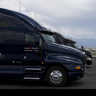
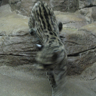
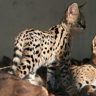
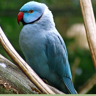

In [4]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [5]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [6]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [7]:
BATCH_SIZE = 32

# Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Batch the validation data
val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Batch the test data
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Helper Functions

Before start creating the models, we define some helper functions to facilitate the training and evaluation process. These functions include:
- `train_model`: This function trains the model using the training data and evaluates it on the validation data. It returns the training history, which includes metrics such as accuracy and loss for each epoch. We included an early stopping mechanism to prevent overfitting by monitoring the validation loss and stopping training if it does not improve for a certain number of epochs. Furthermore, we also included the `ReduceLROnPlateau`callback to reduce the learning rate when the validation loss plateaus, which can help the model converge better.
- `plot_history`: This function plots the training and validation accuracy and loss over epochs to visualize the model's performance during training.

We also create a directory to save the trained models.

In [8]:
import os

# Create a directory to save the models
save_dir = "CustomModels"

# Create the directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory '{save_dir}' created!")

In [ ]:

def train_model(model, train_data, val_data, epochs=25, learning_rate=0.001, patience=5):
    """Train the given model with early stopping and learning rate reduction."""
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )

    callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    )
]
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks
    )
    return history

    

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name="Model"):
    """
    Plots the training and validation accuracy and loss.
    """
    # Extract metrics from the history object
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.ylim(0, 1) 

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Baseline Model

To start with, we implement a simple baseline model using a Convolutional Neural Network (CNN). This model consists of three convolutional layers followed by max pooling layers. This baseline model serves as a reference point for evaluating the performance of more complex models.

Since the model is very simple, it is expected to have a lower accuracy compared to more sophisticated architectures. However, it provides a good starting point for understanding the data and the problem at hand. 

This model overfits relatively quick and achives a test accuracy of 53.51%.

In [ ]:
from tensorflow.keras import layers, models

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential([
        
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [12]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

baseline = build_baseline_model(img_shape, num_classes)
baseline.summary()

/home/iriai/miniconda3/envs/deep_learning/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25


2026-03-19 15:47:53.903910: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dc2600086a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-19 15:47:53.903935: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-19 15:47:53.941096: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-19 15:47:54.151609: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-19 15:47:54.188577: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-19 15:47:54.

 17/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0885 - loss: 2.3459

I0000 00:00:1773931677.566664    2301 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2975 - loss: 1.8643 - val_accuracy: 0.3580 - val_loss: 1.5876 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4560 - loss: 1.4721 - val_accuracy: 0.4400 - val_loss: 1.4596 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5263 - loss: 1.2937 - val_accuracy: 0.5190 - val_loss: 1.3096 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6087 - loss: 1.0853 - val_accuracy: 0.5270 - val_loss: 1.2966 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6830 - loss: 0.9123 - val_accuracy: 0.5430 - val_loss: 1.2907 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7347 - loss: 0.7597 - val_accuracy: 0.5400 - val_loss: 1.3528 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7952 - loss: 0.5892 - val_

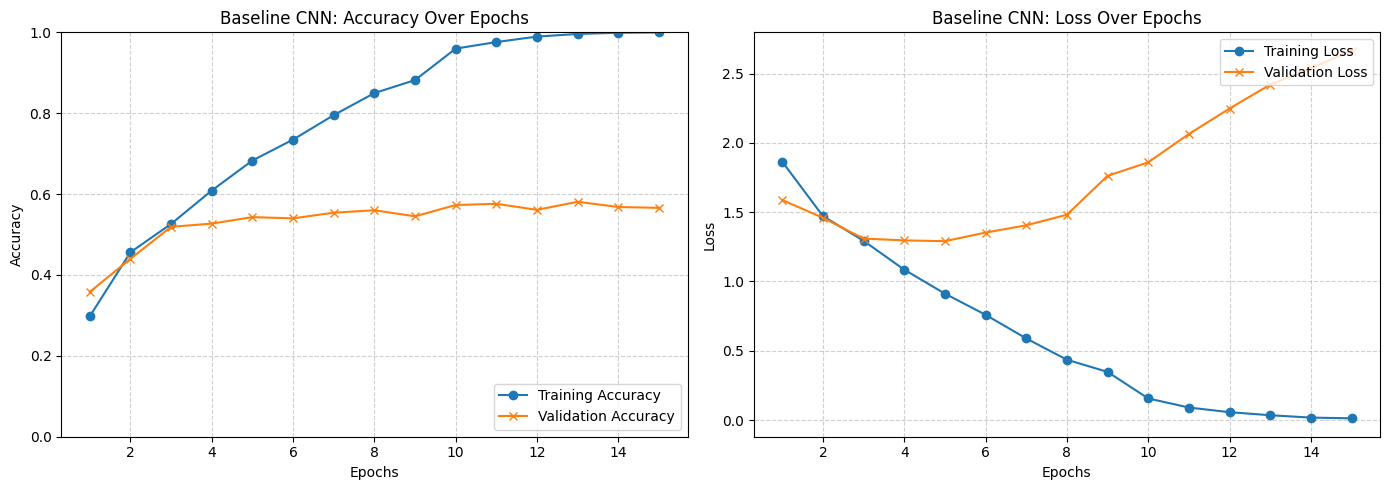

Baseline model saved to 'CustomModels/baseline_cnn.keras'


In [13]:
history = train_model(baseline, train_data, val_data)
plot_history(history, model_name="Baseline CNN")

# Save the baseline model
baseline.save("CustomModels/baseline_cnn.keras")
print("Baseline model saved to 'CustomModels/baseline_cnn.keras'")

In [14]:
# Load the baseline model
try:
    baseline = tf.keras.models.load_model("CustomModels/baseline_cnn.keras")
    print("Baseline model loaded successfully from 'CustomModels/baseline_cnn.keras'")
except Exception as e:
    print(f"Error loading baseline model: {e}")
    exit(1)

test_loss, test_accuracy = baseline.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Baseline model loaded successfully from 'CustomModels/baseline_cnn.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5386 - loss: 1.3886
Test Accuracy: 53.86%
Test Loss: 1.3886


# Custom CNN

To improve the performance of the baseline model, we design several custom CNN architectures. Each model is evaluated on the validation set to determine the best configuration. After that, we test the best model on the test set to evaluate its performance.

Since the training process can be time-consuming, we save the trained models with the best validation accuracy to avoid retraining them in the future. This allows us to quickly load the models and evaluate them on the test set without having to go through the training process again. The best hyperparameters are also saved in a json file for future reference and reproducibility.

### First Model

The first addition that we make to the baseline model is the inclusion of Dropout layers. Dropout is a regularization technique that helps prevent overfitting by randomly setting a fraction of input units to zero during training. This encourages the model to learn more robust features and reduces the likelihood of overfitting.

The model is tested with different dropout and learning rate values with the validation set. The best configuration is a dropout of 0.3 and a learning rate of 0.001, which achieves a test accuracy of 57.25%.

The inclusion of a Dropout layer helps to mitigate overfitting and improves the generalization of the model, leading to better performance on the test set compared to the baseline model. Despite this, the model still overfits relatively quickly, indicating that further regularization techniques or architectural changes may be necessary to achieve better performance.

In [ ]:
from tensorflow.keras import layers, models

def dropout_model(dropout_rate=0.5):
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes


    model = models.Sequential([
        
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model



In [16]:
model = dropout_model()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,610 (4.86 MB)

 Trainable params: 1,273,610 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

-----Training with learning rate: 0.001, Dropout rate: 0.3-----
Epoch 1/50


2026-03-19 15:48:27.568480: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-19 15:48:28.287582: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_995', 520 bytes spill stores, 520 bytes spill loads



125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2817 - loss: 1.9392 - val_accuracy: 0.3230 - val_loss: 1.7543 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3865 - loss: 1.6166 - val_accuracy: 0.3970 - val_loss: 1.5110 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4575 - loss: 1.4551 - val_accuracy: 0.5150 - val_loss: 1.3567 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5370 - loss: 1.2585 - val_accuracy: 0.5110 - val_loss: 1.3279 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5847 - loss: 1.1344 - val_accuracy: 0.5510 - val_loss: 1.2155 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6428 - loss: 0.9712 - val_accuracy: 0.5620 - val_loss: 1.1821 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6925 - loss: 0.8429 - val_

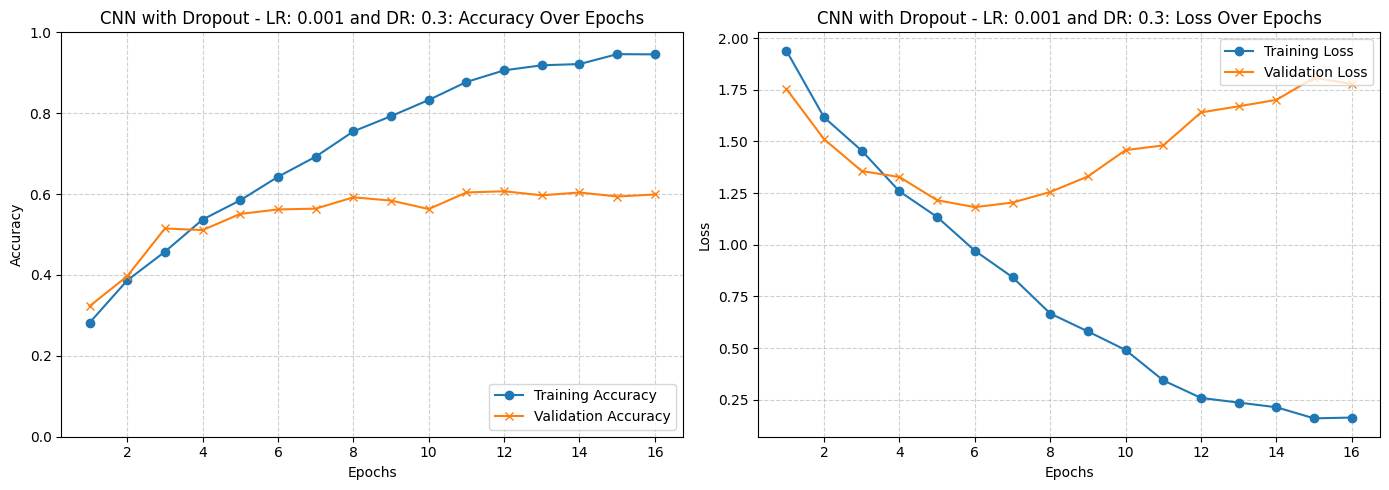

-----Training with learning rate: 0.001, Dropout rate: 0.5-----
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1883 - loss: 2.1611 - val_accuracy: 0.3300 - val_loss: 1.7975 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3180 - loss: 1.7863 - val_accuracy: 0.3800 - val_loss: 1.5664 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3632 - loss: 1.6531 - val_accuracy: 0.4480 - val_loss: 1.4614 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3975 - loss: 1.5522 - val_accuracy: 0.4690 - val_loss: 1.4157 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4240 - loss: 1.4733 - val_accuracy: 0.4780 - val_loss: 1.3882 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4778 - loss: 1.3745 - val_accuracy: 0.5120 - val_loss: 1.3151 - learning_rate: 0.0010
Epoch 7/50
125/125

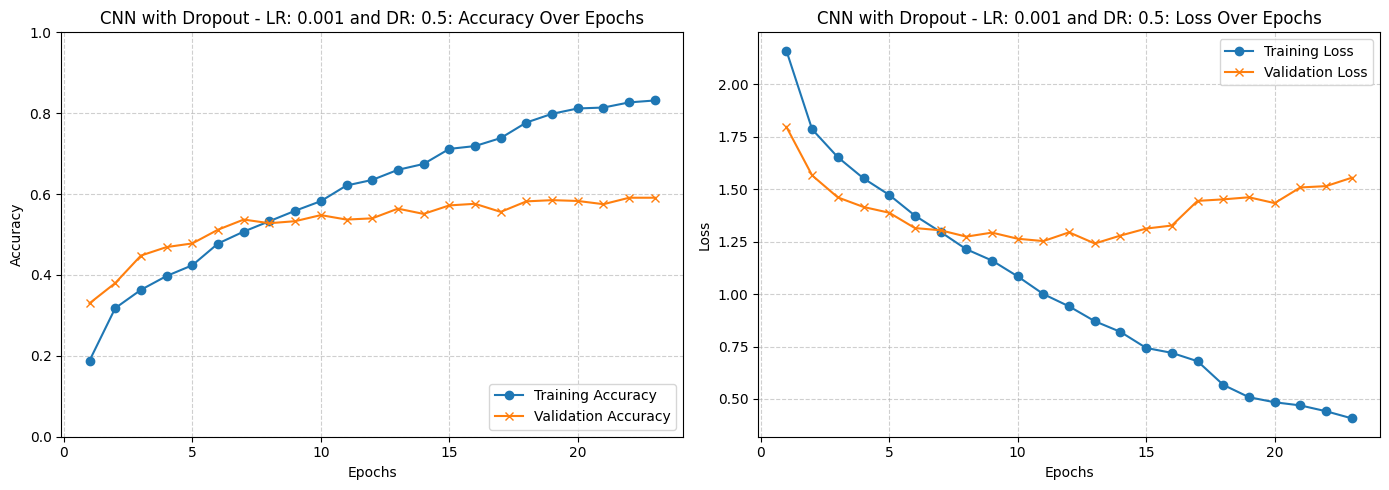

-----Training with learning rate: 0.0001, Dropout rate: 0.3-----
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.2457 - loss: 1.9566 - val_accuracy: 0.3200 - val_loss: 1.6631 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3792 - loss: 1.6224 - val_accuracy: 0.4210 - val_loss: 1.4893 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4563 - loss: 1.4300 - val_accuracy: 0.4730 - val_loss: 1.3718 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5347 - loss: 1.2706 - val_accuracy: 0.5300 - val_loss: 1.2940 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5822 - loss: 1.1320 - val_accuracy: 0.5480 - val_loss: 1.2325 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6375 - loss: 0.9759 - val_accuracy: 0.5440 - val_loss: 1.3241 - learning_rate: 0.0010
Epoch 7/50
125/12

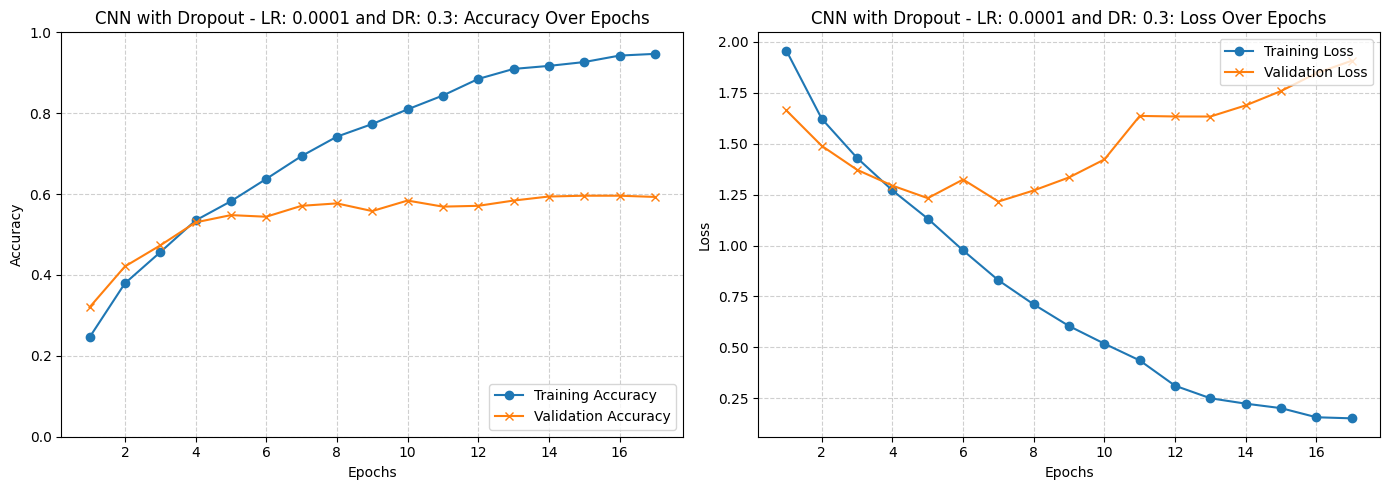

-----Training with learning rate: 0.0001, Dropout rate: 0.5-----
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2122 - loss: 2.0929 - val_accuracy: 0.2740 - val_loss: 1.8568 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3145 - loss: 1.8358 - val_accuracy: 0.4000 - val_loss: 1.6633 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3462 - loss: 1.7026 - val_accuracy: 0.4310 - val_loss: 1.5526 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3898 - loss: 1.6003 - val_accuracy: 0.4420 - val_loss: 1.4656 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4295 - loss: 1.5057 - val_accuracy: 0.4220 - val_loss: 1.4075 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4525 - loss: 1.4459 - val_accuracy: 0.5030 - val_loss: 1.3384 - learning_rate: 0.0010
Epoch 7/50
125/12

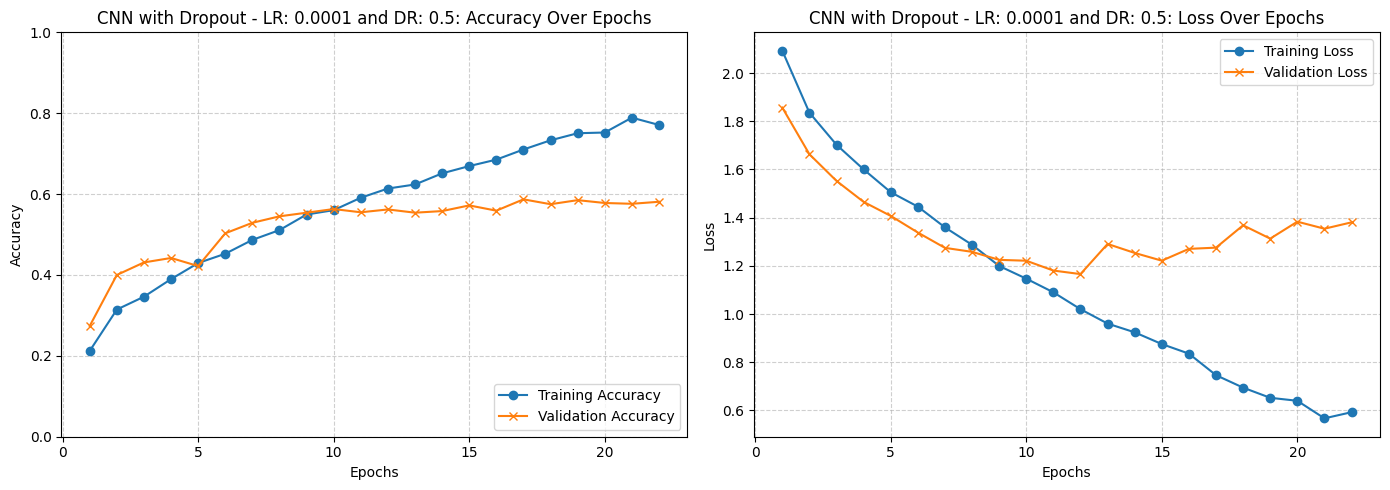

Best Hyperparameters: Learning Rate = 0.0001, Dropout Rate = 0.3
Best model file renamed to 'CustomModels/dropout_cnn_lr_0.0001_dr_0.3.keras'
Best hyperparameters saved to 'CustomModels/dropout_cnn_hyperparams.json'


In [17]:
import json
import os

learning_rates = [0.001, 0.0001]
dropout_rates = [0.3, 0.5]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    for dr in dropout_rates:
        print(f"-----Training with learning rate: {lr}, Dropout rate: {dr}-----")
        model = dropout_model(dropout_rate=dr)
        history = train_model(model, train_data, val_data, epochs=50)

        # Find the epoch early stopping restored weights to (lowest val_loss)
        best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
        best_epoch_val_acc = history.history['val_accuracy'][best_epoch]

        # Save the best model based on validation accuracy
        if best_epoch_val_acc > best_val_acc:
            best_val_acc = best_epoch_val_acc

            try:
                model.save(f"CustomModels/dropout_cnn.keras")
                print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
                best_hyperparams = [lr, dr]
            except Exception as e:
                print(f"Error saving model: {e}")
                exit(1)
            


        plot_history(history, model_name=f"CNN with Dropout - LR: {lr} and DR: {dr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}, Dropout Rate = {best_hyperparams[1]}")

# Rename the best model file to include the hyperparameters for clarity
try:
    lr, dr = best_hyperparams
    os.rename("CustomModels/dropout_cnn.keras", f"CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras")
    print(f"Best model file renamed to 'CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras'")
except Exception as e:
    print(f"Error renaming model file: {e}")
    exit(1)
    
# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0],
    'dropout_rate': best_hyperparams[1]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "dropout_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/dropout_cnn_hyperparams.json'")

In [18]:
import json
# Load the best model
json_path = "CustomModels/dropout_cnn_hyperparams.json"
try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']
    dr = hyperparams['dropout_rate']
    model = tf.keras.models.load_model(f"CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras")
    print(f"Best model loaded successfully from 'CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras'")

except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)

# Evaluate the best model on the test set
    
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/dropout_cnn_lr_0.0001_dr_0.3.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5725 - loss: 1.2625
Test Accuracy: 57.25%
Test Loss: 1.2625


### Second Model

For the second model, we implement data augmentation techniques to artificially increase the size of the training dataset. Data augmentation helps to improve the generalization of the model by creating new training examples through random transformations of the existing images, such as rotations, shifts, flips, and zooms. Since the dataset is relatively small (5000 training samples), data augmentation can help to prevent overfitting and improve the model's performance on unseen data.

After testing different configurations, the best results are obtained with a dropout of 0.5, a learning rate of 0.001, and a rotation factor of 0.1. This model achieves a test accuracy of 64.24%, which is a significant improvement over the previous model, indicating that data augmentation has a positive impact on the model's performance.

In [ ]:
from tensorflow.keras import layers, models

def augmen_model(dropout_rate=0.5, rotation_factor = 0.1):
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

    model = models.Sequential([
        layers.InputLayer(input_shape=input_shape),
        # Data Augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(rotation_factor),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

model = augmen_model()

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_17 (RandomFlip)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_9               │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_161 (Conv2D)             │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_162 (Conv2D)             │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_163 (Conv2D)             │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,610 (4.86 MB)

 Trainable params: 1,273,610 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

-----Training with learning rate: 0.001, Dropout rate: 0.5, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1863 - loss: 2.1526 - val_accuracy: 0.2830 - val_loss: 1.9334 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2822 - loss: 1.9101 - val_accuracy: 0.3190 - val_loss: 1.6969 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3038 - loss: 1.7805 - val_accuracy: 0.3390 - val_loss: 1.5795 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3388 - loss: 1.6893 - val_accuracy: 0.4220 - val_loss: 1.5312 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3500 - loss: 1.6660 - val_accuracy: 0.4630 - val_loss: 1.4555 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3635 - loss: 1.6308 - val_accuracy: 0.4240 - val_loss: 1.4558 - learning_rat

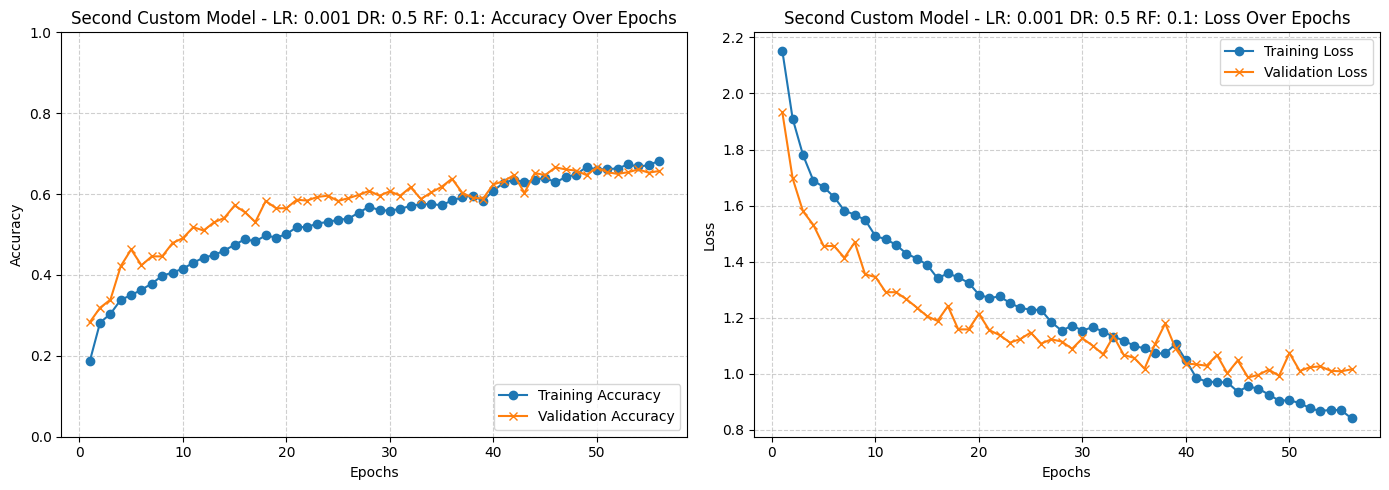

-----Training with learning rate: 0.001, Dropout rate: 0.5, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1462 - loss: 2.2342 - val_accuracy: 0.2090 - val_loss: 2.0832 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2307 - loss: 1.9959 - val_accuracy: 0.2740 - val_loss: 1.8552 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2650 - loss: 1.9221 - val_accuracy: 0.3060 - val_loss: 1.8075 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2738 - loss: 1.8758 - val_accuracy: 0.3100 - val_loss: 1.7641 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2940 - loss: 1.8209 - val_accuracy: 0.3250 - val_loss: 1.7297 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3038 - loss: 1.7909 - val_accuracy: 0.3310 - val_loss: 1.7321 - learning_rate

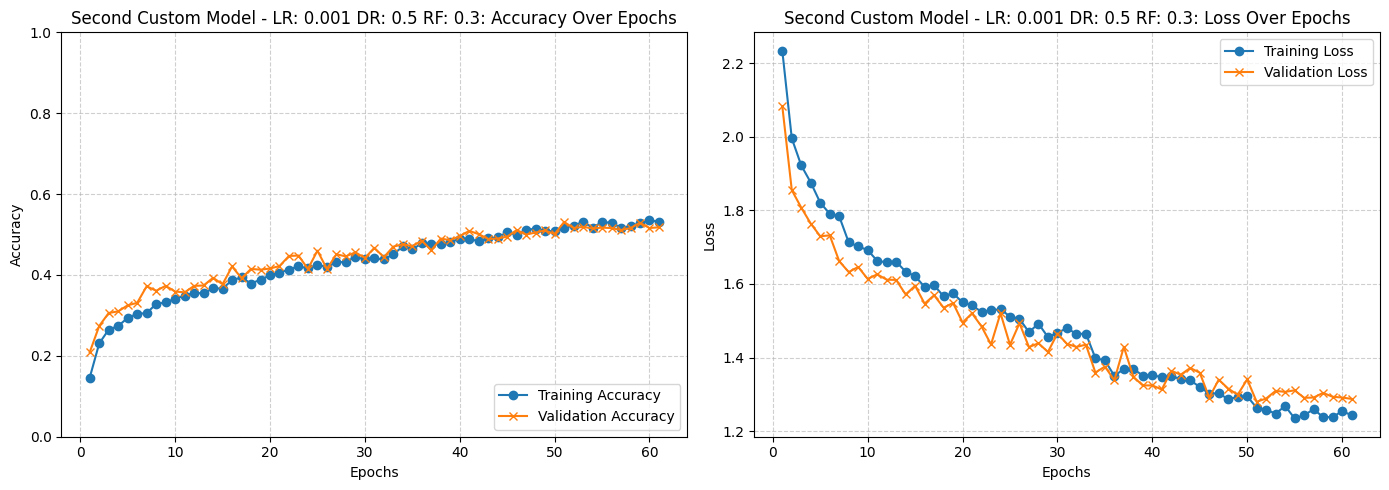

-----Training with learning rate: 0.001, Dropout rate: 0.7, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1495 - loss: 2.2218 - val_accuracy: 0.2540 - val_loss: 1.9708 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2218 - loss: 2.0342 - val_accuracy: 0.2950 - val_loss: 1.8111 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2522 - loss: 1.9208 - val_accuracy: 0.3390 - val_loss: 1.7241 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2797 - loss: 1.8492 - val_accuracy: 0.3370 - val_loss: 1.6346 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2965 - loss: 1.7898 - val_accuracy: 0.3340 - val_loss: 1.5930 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2968 - loss: 1.7642 - val_accuracy: 0.3610 - val_loss: 1.5944 - learning_rat

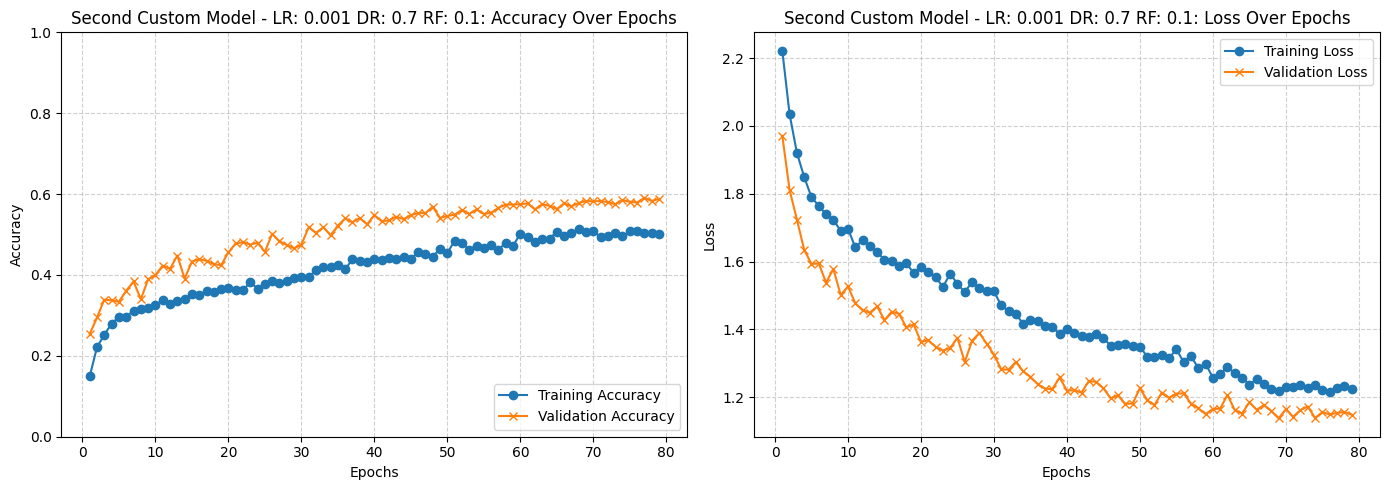

-----Training with learning rate: 0.001, Dropout rate: 0.7, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1308 - loss: 2.2431 - val_accuracy: 0.1860 - val_loss: 2.1453 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1943 - loss: 2.1474 - val_accuracy: 0.2230 - val_loss: 2.0531 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2192 - loss: 2.0506 - val_accuracy: 0.2270 - val_loss: 1.9640 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2435 - loss: 1.9643 - val_accuracy: 0.2850 - val_loss: 1.8889 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2465 - loss: 1.9204 - val_accuracy: 0.3030 - val_loss: 1.8388 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2560 - loss: 1.8762 - val_accuracy: 0.2980 - val_loss: 1.7842 - learning_rat

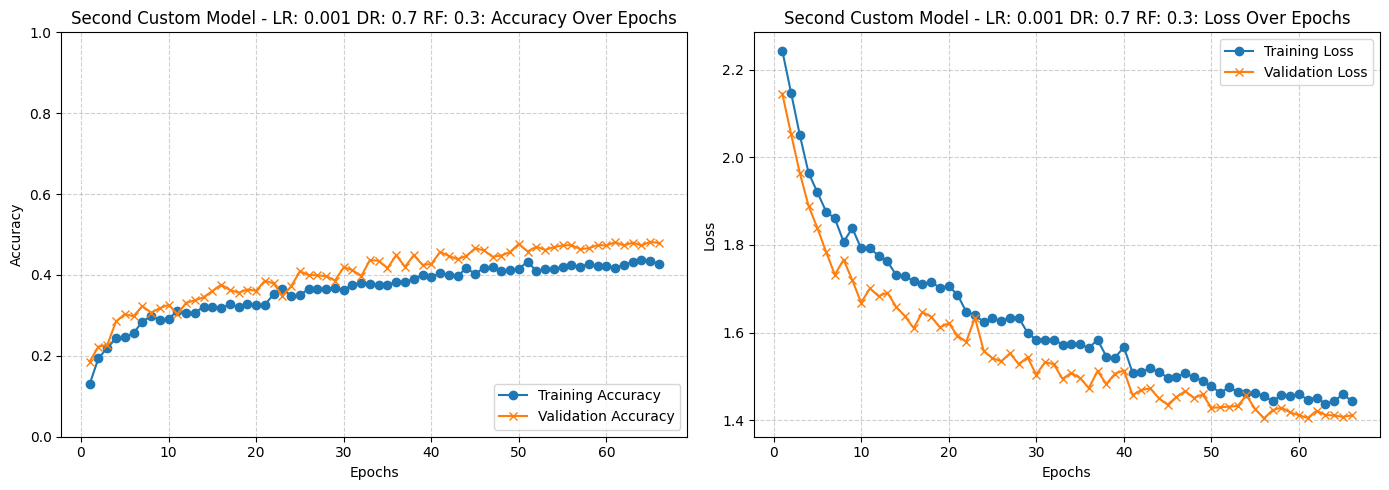

-----Training with learning rate: 0.0005, Dropout rate: 0.5, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.2030 - loss: 2.1213 - val_accuracy: 0.2870 - val_loss: 1.8977 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2945 - loss: 1.9162 - val_accuracy: 0.3630 - val_loss: 1.6825 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3195 - loss: 1.8198 - val_accuracy: 0.3860 - val_loss: 1.5984 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3465 - loss: 1.7324 - val_accuracy: 0.4220 - val_loss: 1.5781 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3570 - loss: 1.7063 - val_accuracy: 0.4290 - val_loss: 1.5229 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3582 - loss: 1.6601 - val_accuracy: 0.4590 - val_loss: 

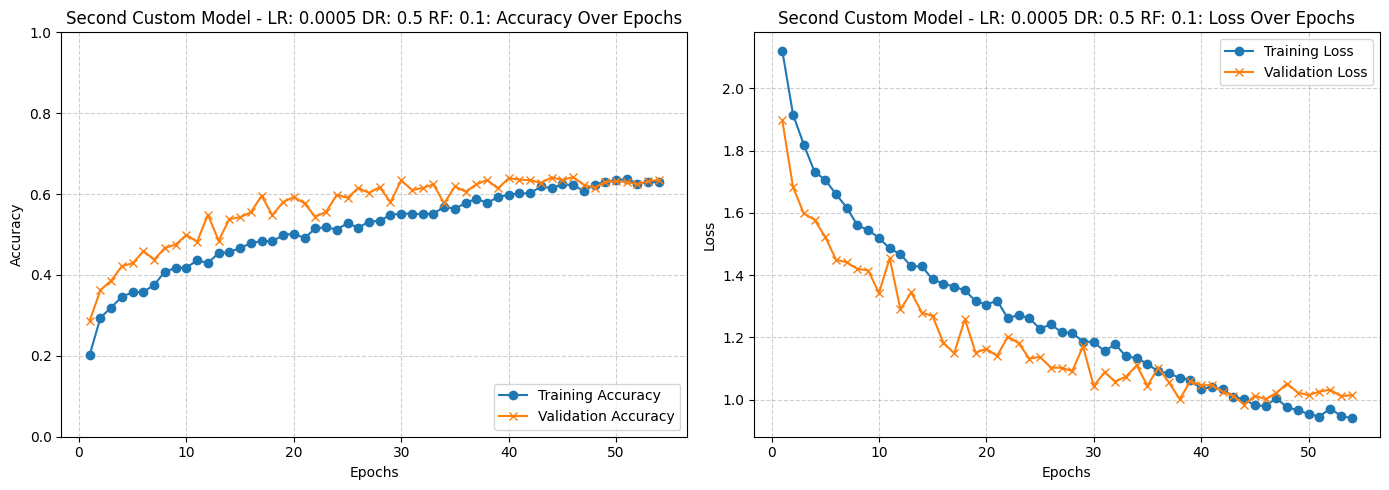

-----Training with learning rate: 0.0005, Dropout rate: 0.5, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1675 - loss: 2.2342 - val_accuracy: 0.2630 - val_loss: 2.0645 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2542 - loss: 2.0229 - val_accuracy: 0.3040 - val_loss: 1.8822 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2650 - loss: 1.9499 - val_accuracy: 0.2960 - val_loss: 1.8482 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2907 - loss: 1.8737 - val_accuracy: 0.3500 - val_loss: 1.7410 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3013 - loss: 1.8204 - val_accuracy: 0.3460 - val_loss: 1.6884 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3262 - loss: 1.7735 - val_accuracy: 0.3730 - val_loss: 

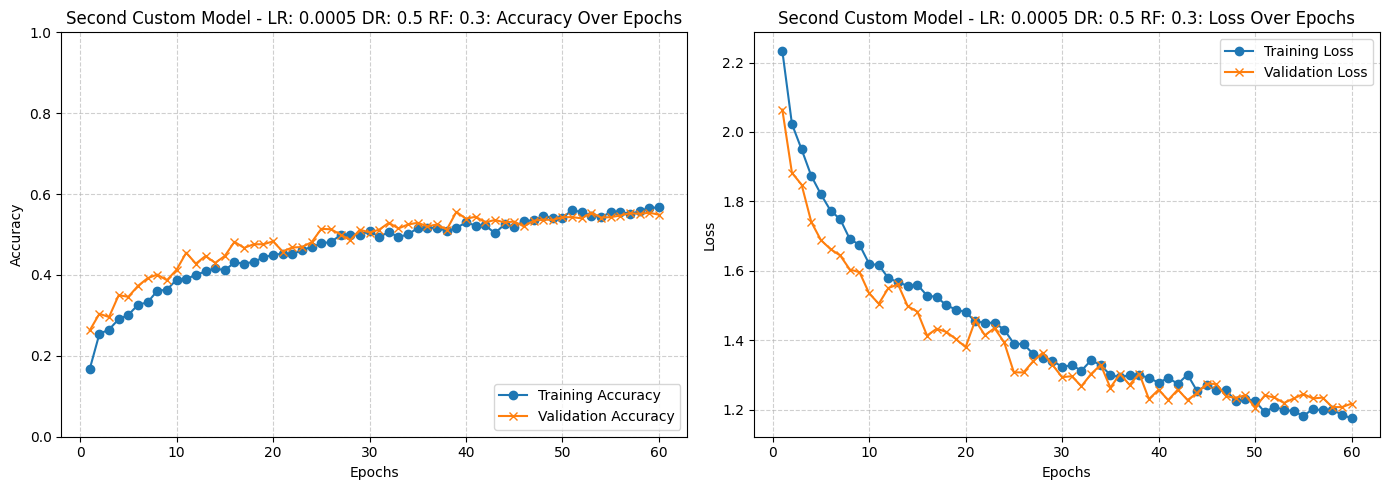

-----Training with learning rate: 0.0005, Dropout rate: 0.7, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1600 - loss: 2.1903 - val_accuracy: 0.2820 - val_loss: 1.9598 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2407 - loss: 2.0141 - val_accuracy: 0.3280 - val_loss: 1.7824 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2682 - loss: 1.9293 - val_accuracy: 0.3790 - val_loss: 1.7209 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2792 - loss: 1.8833 - val_accuracy: 0.3980 - val_loss: 1.6272 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2898 - loss: 1.8231 - val_accuracy: 0.4270 - val_loss: 1.6216 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3015 - loss: 1.7918 - val_accuracy: 0.4280 - val_loss: 

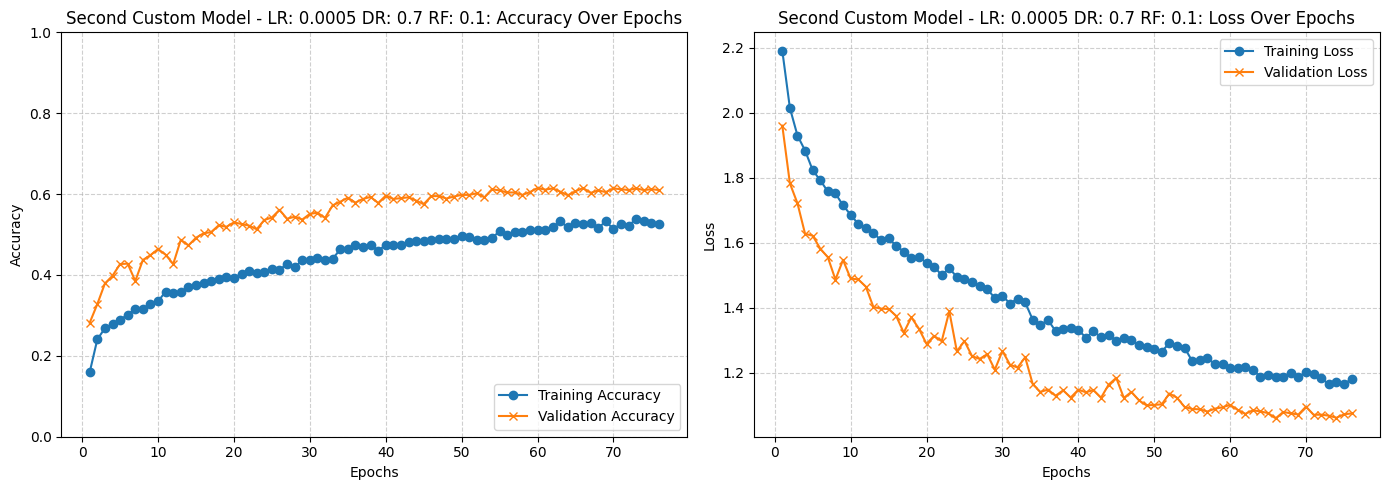

-----Training with learning rate: 0.0005, Dropout rate: 0.7, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.1297 - loss: 2.2720 - val_accuracy: 0.2270 - val_loss: 2.1494 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1920 - loss: 2.1500 - val_accuracy: 0.2130 - val_loss: 2.0505 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2188 - loss: 2.0934 - val_accuracy: 0.2460 - val_loss: 2.0016 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2282 - loss: 2.0298 - val_accuracy: 0.2740 - val_loss: 1.8759 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2380 - loss: 1.9926 - val_accuracy: 0.3120 - val_loss: 1.8624 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2475 - loss: 1.9497 - val_accuracy: 0.3030 - val_loss: 

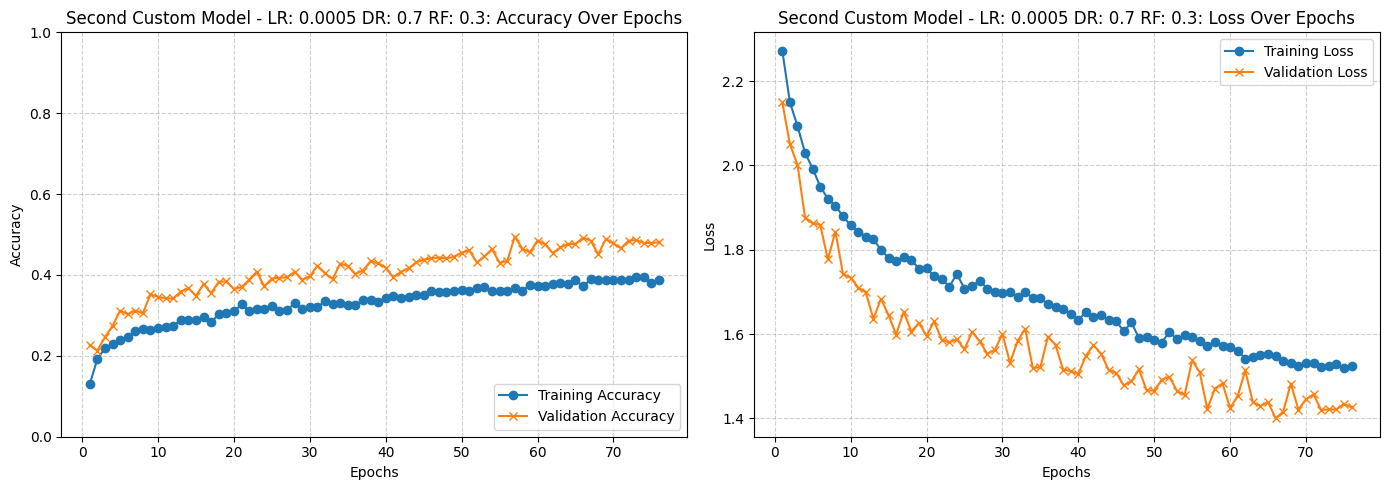

Best Hyperparameters: Learning Rate = 0.001, Dropout Rate = 0.5, Rotation Factor = 0.1
Best model file renamed to 'CustomModels/augmen_cnn_lr_0.001_dr_0.5_rf_0.1.keras'
Best hyperparameters saved to 'CustomModels/augmen_cnn_hyperparams.json'


In [30]:
import json
import os

learning_rates = [0.001, 0.0005]
dropout_rates = [0.5, 0.7]
rotation_factors = [0.1, 0.3]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    for dr in dropout_rates:
        for rf in rotation_factors:
            print(f"-----Training with learning rate: {lr}, Dropout rate: {dr}, Rotation factor: {rf}-----")
            model = augmen_model(dropout_rate=dr, rotation_factor=rf)
            history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
            
            # Find the epoch early stopping restored weights to (lowest val_loss)
            best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
            best_epoch_val_acc = history.history['val_accuracy'][best_epoch]
            # Save the best model based on validation accuracy
            if best_epoch_val_acc > best_val_acc:
                best_val_acc = best_epoch_val_acc
                try:
                    model.save(f"CustomModels/augmen_cnn.keras")
                    best_hyperparams = [lr, dr, rf]
                    print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
                except Exception as e:
                    print(f"Error saving model: {e}")
                    exit(1)
    
            plot_history(history, model_name=f"Second Custom Model - LR: {lr} DR: {dr} RF: {rf}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}, Dropout Rate = {best_hyperparams[1]}, Rotation Factor = {best_hyperparams[2]}")

# Rename the best model file to include the hyperparameters for clarity
try:
    lr, dr, rf = best_hyperparams
    os.rename("CustomModels/augmen_cnn.keras", f"CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras")
    print(f"Best model file renamed to 'CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras'")
except Exception as e:
    print(f"Error renaming model file: {e}")
    exit(1)
    
# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0],
    'dropout_rate': best_hyperparams[1],
    'rotation_factor': best_hyperparams[2]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "augmen_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/augmen_cnn_hyperparams.json'")

In [31]:
import json
# Load the best model
json_path = "CustomModels/augmen_cnn_hyperparams.json"

try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']
    dr = hyperparams['dropout_rate']
    rf = hyperparams['rotation_factor']

    model = tf.keras.models.load_model(f"CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras")
    print(f"Best model loaded successfully from 'CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras'")
except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)
# Evaluate the best model on the test set
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/augmen_cnn_lr_0.001_dr_0.5_rf_0.1.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6424 - loss: 1.0313
Test Accuracy: 64.24%
Test Loss: 1.0313


### Third Model

Despite the improvements in performance in comparison to the first and baseline models, the second model still gets a relatively low accuracy. To further enhance the model's performance, we implement a third deeper CNN architecture with more convolutional layers and increased complexity. Dropout layers and data augmentation techniques are also included as they have shown to be effective in the previous models.

Since this third model is deeper than the previous ones, we performed experiments with fewer hyperparameters than the previous models (we only tried three different learning rates with fixed configurations for dropout and data augmentation). This is a limitation related to the computational resources required for training more complex models. Trying more exhaustive hyperparameter searches would be computationally expensive, extending the training time to several hours, even with the use of GPU. 

The best configuration for this model is a learning rate of 0.001. This model achieves a test accuracy of 73.00%, which is a significant improvement over the previous models. The deeper architecture allows the model to learn more complex features from the data, while the dropout and data augmentation techniques help to prevent overfitting and improve generalization. This demonstrates that increasing the depth of the CNN can lead to better performance on the test set when combined with appropriate regularization techniques.

In [ ]:
from tensorflow.keras import layers, models

def conv_block(x, filters, dropout_rate=0.3):
    
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

def improved_model():
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

    inputs = tf.keras.Input(shape=input_shape)

    data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    ], name="augmentation")

    x = data_augmentation(inputs)

    x = conv_block(x, filters=32,  dropout_rate=0.2) 
    x = conv_block(x, filters=64,  dropout_rate=0.2) 
    x = conv_block(x, filters=128, dropout_rate=0.3) 
    x = conv_block(x, filters=256, dropout_rate=0.3) 

    # Extra single conv at the same scale to deepen without another pool
    x = tf.keras.layers.Conv2D(256, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    
    x = tf.keras.layers.GlobalAveragePooling2D()(x) 
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name="Improved_Custom_CNN")



deep_model = improved_model()

deep_model.summary()

Model: "Improved_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,035,754 (7.77 MB)

 Trainable params: 2,031,786 (7.75 MB)

 Non-trainable params: 3,968 (15.50 KB)

-----Training with learning rate: 0.001-----
Epoch 1/100


E0000 00:00:1773933522.884772    1452 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Improved_Custom_CNN_1/dropout_20_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.2233 - loss: 2.7654 - val_accuracy: 0.1090 - val_loss: 2.4495 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.2567 - loss: 2.3012 - val_accuracy: 0.1090 - val_loss: 3.3203 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.2948 - loss: 2.0641 - val_accuracy: 0.1650 - val_loss: 2.2913 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.3368 - loss: 1.8711 - val_accuracy: 0.2560 - val_loss: 2.0295 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.3645 - loss: 1.7413 - val_accuracy: 0.2890 - val_loss: 2.5154 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.4165 - loss: 1.5859 - val_accuracy: 0.3710 - val_loss: 1.7976 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.4365 - loss:

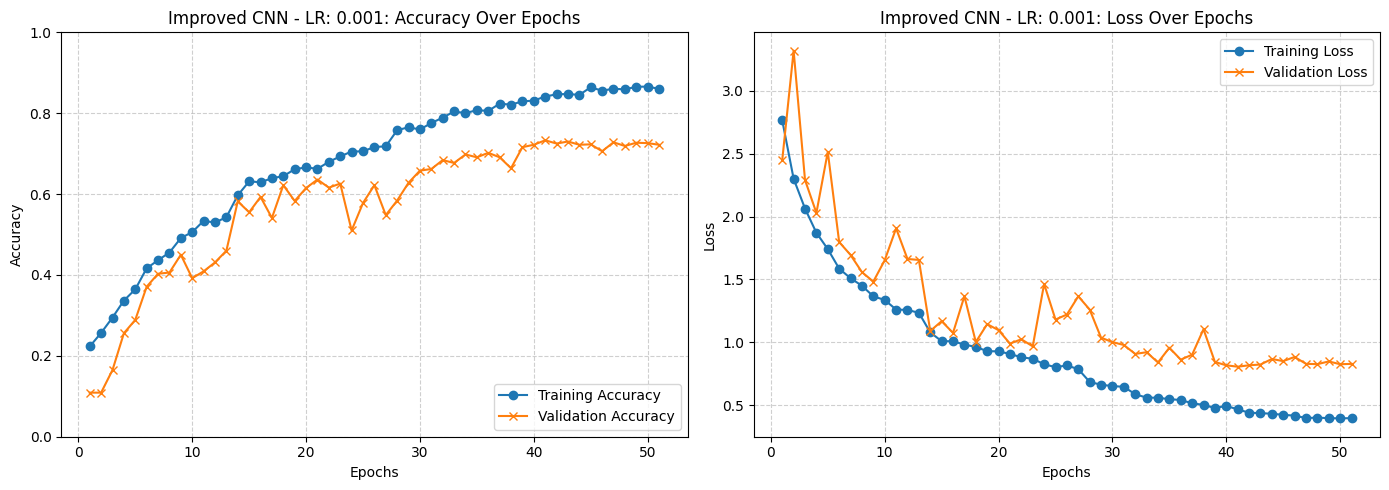

-----Training with learning rate: 0.0005-----
Epoch 1/100


E0000 00:00:1773934135.520490    1452 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Improved_Custom_CNN_1/dropout_26_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.2013 - loss: 2.7377 - val_accuracy: 0.0970 - val_loss: 2.8293 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.2635 - loss: 2.2558 - val_accuracy: 0.0980 - val_loss: 3.1533 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.2995 - loss: 2.1028 - val_accuracy: 0.1210 - val_loss: 3.2960 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.3318 - loss: 1.9353 - val_accuracy: 0.1680 - val_loss: 2.6627 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.3447 - loss: 1.8697 - val_accuracy: 0.2990 - val_loss: 2.0040 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.3915 - loss: 1.6935 - val_accuracy: 0.3560 - val_loss: 1.7785 - learning_rate: 5.0000e-04
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - a

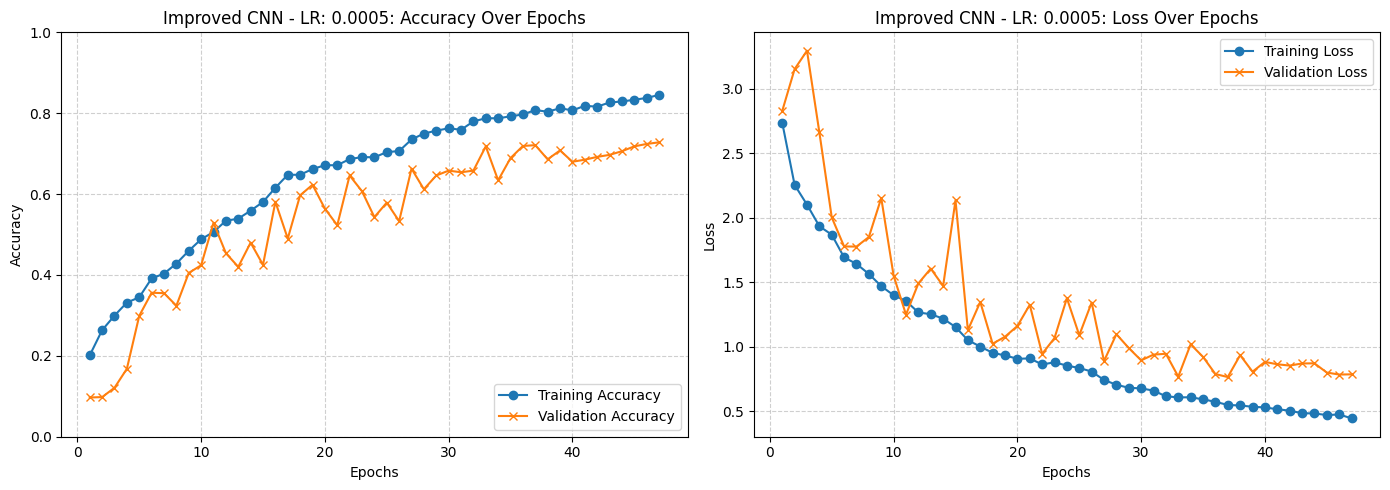

-----Training with learning rate: 0.0001-----
Epoch 1/100


E0000 00:00:1773934689.341997    1452 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Improved_Custom_CNN_1/dropout_32_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.1620 - loss: 3.0677 - val_accuracy: 0.1030 - val_loss: 2.3461 - learning_rate: 1.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.2202 - loss: 2.6194 - val_accuracy: 0.1150 - val_loss: 2.7278 - learning_rate: 1.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.2580 - loss: 2.3618 - val_accuracy: 0.1040 - val_loss: 3.1246 - learning_rate: 1.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.2720 - loss: 2.2819 - val_accuracy: 0.1410 - val_loss: 3.0469 - learning_rate: 1.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3107 - loss: 2.1013
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.2993 - loss: 2.1392 - val_accuracy: 0.1560 - val_loss: 3.1975 - learning_rate: 1.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy

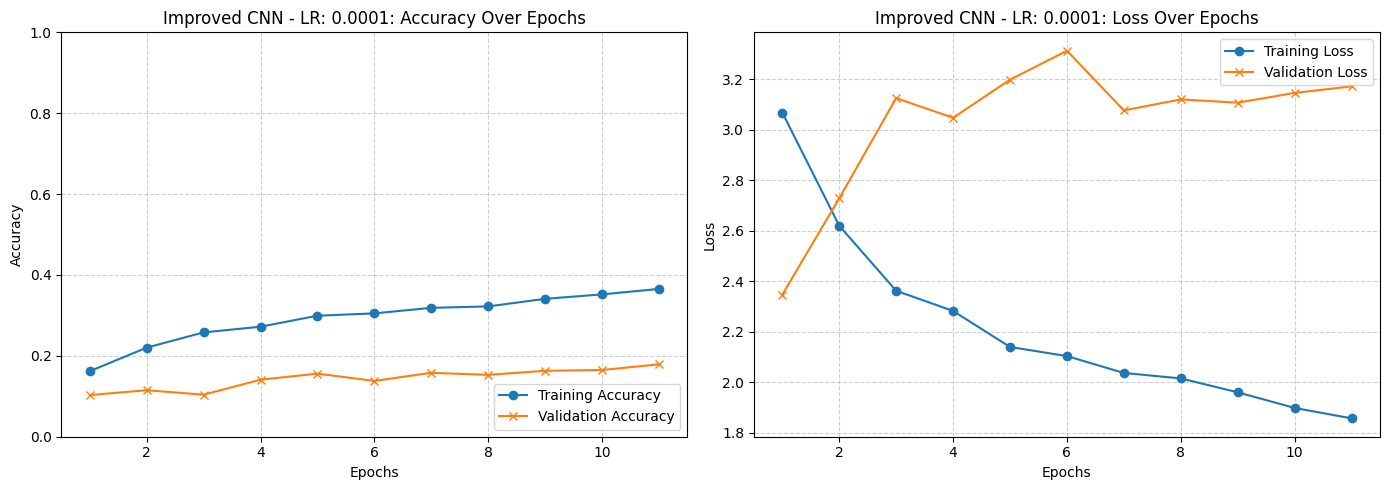

Best Hyperparameters: Learning Rate = 0.001
Best model file renamed to 'CustomModels/improved_cnn_lr_0.001.keras'
Best hyperparameters saved to 'CustomModels/improved_cnn_hyperparams.json'


In [23]:
import json
import os

learning_rates = [0.001, 0.0005, 0.0001]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    print(f"-----Training with learning rate: {lr}-----")
    model = improved_model()
    history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
            
    # Find the epoch early stopping restored weights to (lowest val_loss)
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
    best_epoch_val_acc = history.history['val_accuracy'][best_epoch]
    
    # Save the best model based on validation accuracy
    if best_epoch_val_acc > best_val_acc:
        best_val_acc = best_epoch_val_acc
        try:
            model.save(f"CustomModels/improved_cnn.keras")
            best_hyperparams = [lr]
            print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
        except Exception as e:
            print(f"Error saving model: {e}")
            exit(1)
    
    plot_history(history, model_name=f"Improved CNN - LR: {lr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}")

# Rename the best model file to include the hyperparameters for clarity
try:
    lr = best_hyperparams[0]
    os.rename("CustomModels/improved_cnn.keras", f"CustomModels/improved_cnn_lr_{lr}.keras")
    print(f"Best model file renamed to 'CustomModels/improved_cnn_lr_{lr}.keras'")
except Exception as e:
    print(f"Error renaming model file: {e}")
    exit(1)
    
# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "improved_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/improved_cnn_hyperparams.json'")

In [24]:
import json
json_path = "CustomModels/improved_cnn_hyperparams.json"

try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']

    model = tf.keras.models.load_model(f"CustomModels/improved_cnn_lr_{lr}.keras")
    print(f"Best model loaded successfully from 'CustomModels/improved_cnn_lr_{lr}.keras'")
except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)

test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/improved_cnn_lr_0.001.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7300 - loss: 0.8085
Test Accuracy: 73.00%
Test Loss: 0.8085


### ResNet

Finally, we implement a ResNet architecture, a type of CNN that uses skip connections to allow gradients to flow more easily through the network during training. The ResNet architecture is known for its strong performance on image classification tasks. By implementing it, we aim to further improve the accuracy of our model on the test set.

Similarly to the third model, we only test three different learning rates with fixed configurations for dropout and data augmentation due to computational constraints.

In [25]:
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Projection shortcut
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same',
                                 use_bias=False,
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def resNet_model():
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes
    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.1)(x)


    x = layers.Conv2D(64, (3, 3), padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)

    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)
    
resNet_model().summary()

Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_13      │ (None, 96, 96, 3) │          0 │ input_layer_23[0… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_4       │ (None, 96, 96, 3) │          0 │ random_flip_13[0… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_4   │ (None, 96, 96, 3) │          0 │ random_zoom_4[0]… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 96, 96,    │      1,728 │ random_contrast_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_81[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_36[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_82[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_37[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_83[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_36[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 96, 96,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_84[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 96, 96,    │          0 │ batch_normalizat

 Total params: 11,315,402 (43.16 MB)

 Trainable params: 11,304,266 (43.12 MB)

 Non-trainable params: 11,136 (43.50 KB)

-----Training with learning rate: 0.001-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 375ms/step - accuracy: 0.2215 - loss: 2.8950 - val_accuracy: 0.1080 - val_loss: 3.0254 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 377ms/step - accuracy: 0.2797 - loss: 2.5357 - val_accuracy: 0.1000 - val_loss: 3.5323 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.2920 - loss: 2.3735 - val_accuracy: 0.1430 - val_loss: 2.9370 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 378ms/step - accuracy: 0.3122 - loss: 2.2548 - val_accuracy: 0.1490 - val_loss: 3.5211 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.3440 - loss: 2.1439 - val_accuracy: 0.2570 - val_loss: 2.5978 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 381ms/step - accuracy: 0.3730 - loss: 2.0746 - val_accuracy: 0.2740 - val_loss: 2.4821 - learning_rate: 0.0010
Epoch 7/100
125/125

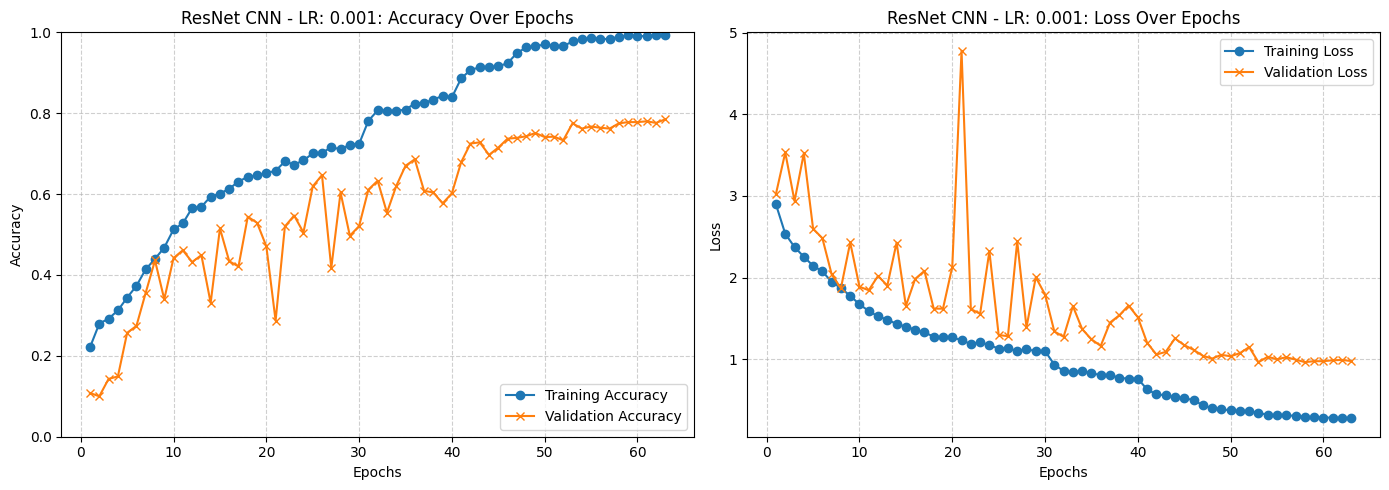

-----Training with learning rate: 0.0005-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 55s 380ms/step - accuracy: 0.2315 - loss: 2.8818 - val_accuracy: 0.1430 - val_loss: 2.8663 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.2733 - loss: 2.5250 - val_accuracy: 0.1340 - val_loss: 3.5560 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 382ms/step - accuracy: 0.3250 - loss: 2.3532 - val_accuracy: 0.1410 - val_loss: 4.4829 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.3587 - loss: 2.2211 - val_accuracy: 0.2380 - val_loss: 2.6027 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 385ms/step - accuracy: 0.3850 - loss: 2.1168 - val_accuracy: 0.3740 - val_loss: 2.3047 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.4108 - loss: 2.0337 - val_accuracy: 0.3660 - val_loss: 2.4199 - learning_rate: 5.000

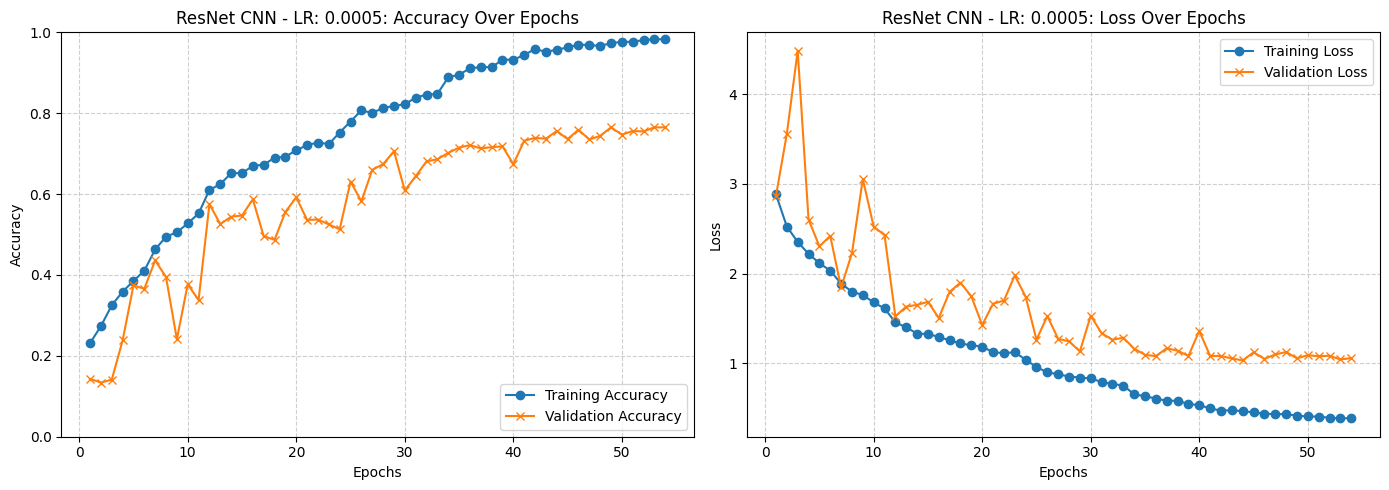

-----Training with learning rate: 0.0001-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 384ms/step - accuracy: 0.2410 - loss: 2.8513 - val_accuracy: 0.1170 - val_loss: 3.3605 - learning_rate: 1.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 373ms/step - accuracy: 0.2975 - loss: 2.5638 - val_accuracy: 0.0860 - val_loss: 3.8725 - learning_rate: 1.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 385ms/step - accuracy: 0.3338 - loss: 2.4057 - val_accuracy: 0.1570 - val_loss: 3.4128 - learning_rate: 1.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 0.3772 - loss: 2.2578 - val_accuracy: 0.1890 - val_loss: 3.2967 - learning_rate: 1.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 388ms/step - accuracy: 0.4070 - loss: 2.2015 - val_accuracy: 0.4130 - val_loss: 1.9828 - learning_rate: 1.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 396ms/step - accuracy: 0.4415 - loss: 2.0880 - val_accuracy: 0.4480 - val_loss: 2.1266 - learning_rate: 1.000

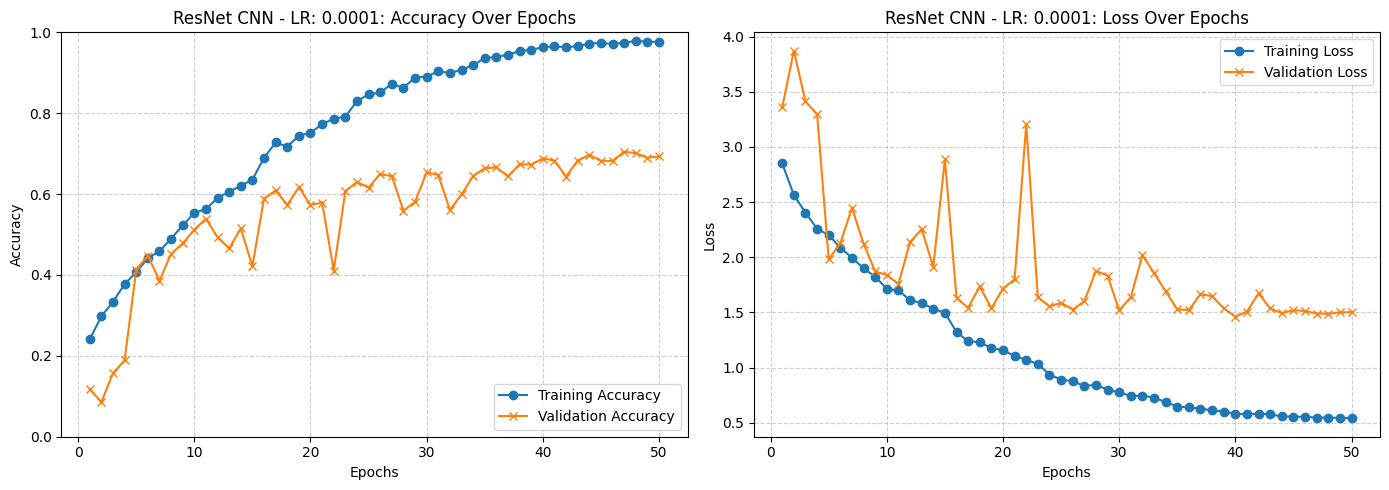

Best Hyperparameters: Learning Rate = 0.001
Best model file renamed to 'CustomModels/ResNet_cnn_lr_0.001.keras'
Best hyperparameters saved to 'CustomModels/ResNet_cnn_hyperparams.json'


In [26]:
import json
import os

learning_rates = [0.001, 0.0005, 0.0001]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    print(f"-----Training with learning rate: {lr}-----")
    model = resNet_model()
    history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
            
    # Find the epoch early stopping restored weights to (lowest val_loss)
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
    best_epoch_val_acc = history.history['val_accuracy'][best_epoch]
    
    # Save the best model based on validation accuracy
    if best_epoch_val_acc > best_val_acc:
        best_val_acc = best_epoch_val_acc
        try:
            model.save(f"CustomModels/ResNet_cnn.keras")
            best_hyperparams = [lr]
            print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
        except Exception as e:
            print(f"Error saving model: {e}")
            exit(1)
    
    plot_history(history, model_name=f"ResNet CNN - LR: {lr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}")

# Rename the best model file to include the hyperparameters for clarity
try:
    lr = best_hyperparams[0]
    os.rename("CustomModels/ResNet_cnn.keras", f"CustomModels/ResNet_cnn_lr_{lr}.keras")
    print(f"Best model file renamed to 'CustomModels/ResNet_cnn_lr_{lr}.keras'")
except Exception as e:
    print(f"Error renaming model file: {e}")
    exit(1)
    
# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "ResNet_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/ResNet_cnn_hyperparams.json'")

In [27]:
import json
json_path = "CustomModels/ResNet_cnn_hyperparams.json"

try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']

    model = tf.keras.models.load_model(f"CustomModels/ResNet_cnn_lr_{lr}.keras")
    print(f"Best model loaded successfully from 'CustomModels/ResNet_cnn_lr_{lr}.keras'")
except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)

test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/ResNet_cnn_lr_0.001.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.7775 - loss: 0.9681
Test Accuracy: 77.75%
Test Loss: 0.9681


# Model Comparison

### Comparison between different configurations

First, we are going to compare the performance of the models with different configurations on the validation set to see how the changes in hyperparameters affect the model's performance.

For the first model:

| **Learning Rate** | **Dropout Rate** | **Validation Accuracy** | **Early Stopping Epoch** |
|:---:|:---:|:-----------------------:|:-----------------------------:|
|       0.001       	|        0.3       	|          56.20%    |16                            	|
|       0.001       	|        0.5       	|          56.40%         	|23                            	|
|       0.0001      	|        0.3       	|          57.10%         	|17                            	|
|       0.0001      	|        0.5       	|          56.20%         	|22                            	|


For the second model:

| Learning Rate | Dropout Rate | Rotation Factor | Validation Accuracy | Early Stopping Epoch |
| :---: | :---: | :---: | :---: | :---: |
| 0.001 | 0.5 | 0.1 | 66.60% | 56 |
| 0.001 | 0.5 | 0.3 | 53.10% | 61 |
| 0.001 | 0.7 | 0.1 | 58.30% | 79 |
| 0.001 | 0.7 | 0.3 | 47.40% | 66 |
| 0.0005 | 0.5 | 0.1 | 64.10% | 54 |
| 0.0005 | 0.5 | 0.3 | 54.30% | 60 |
| 0.0005 | 0.7 | 0.1 | 61.50% | 76 |
| 0.0005 | 0.7 | 0.3 | 49.20% | 76 |

For the third model:

| **Learning Rate** 	| **Validation Accuracy** 	| **Early Stopping Epoch** 	|
|:-----------------:|:-----------------------:|:-------------------------:|
|       0.001       	|          73.30%         	|51                         |
|       0.0005      	|          72.10%         	|47                         |
|       0.0001      	|          10.30%         	|11                         |


For the ResNet model:

| **Learning Rate** 	| **Validation Accuracy** 	| **Early Stopping Epoch** 	|
|:-----------------:|:-----------------------:|:------------------------:|
|       0.001       	|          77.50%         	|            63            	|
|       0.0005      	|          75.60%         	|            54            	|
|       0.0001      	|          68.80%         	|            50            	|


In general, we can see that the changes in hyperparameters don't have a significant impact on the validation accuracy reached, with all the configurations achieving similar results. It seems that the differences mainly affect the number of epochs needed to reach their best validation accuracy, with some configurations overfitting faster than others. The exception to this is the second model, where the configuration highly affects the validation accuracy. Particularly, we can see that a dropout of 0.5 and a rotation factor of 0.1 significantly improve the validation accuracy compared to the other configurations. It makes sense that this is the model in which we can see the biggest impact of the hyperparameters, since is the model for which we performed the most exhaustive hyperparameter search.

It is, however, worth noting the exepcionally low validation accuracy achieved by the third model with a learning rate of 0.0001, which indicates that the model is not learning effectively with this configuration, possibly due to the learning rate being too low for the model to converge properly. In fact, this model stops at epoch 11, which, given that we are using a patience of 10 for early stopping, means that the model is not improving its performance on the validation set after epoch 1, basically not learning at all. For the ResNet, a similar behavior is observed with the learning rate of 0.0001, which also achieves a significantly lower validation accuracy compared to the other configurations, although the difference is not as extreme as in the third model.

### Comparison between models

The following table summarizes the test and validation accuracies achieved by each model with the best configurations:


|               	    | Baseline 	| First Model 	| Second Model 	| Third Model 	| ResNet 	|
|:-------------:|:--------:|:-----------:|:------------:|:-----------:|:------:|
| Validation Accuracy 	|  54.30%  	|    57.10%   	|    66.60%    	|    73.30%   	| 76.91% 	|
| Test Accuracy 	    |  53.86%  	|    57.25%   	|    64.24%    	|    73.00%   	| 77.75% 	|


As it can be seen, the performance of the models improves significantly as we move from the baseline model to the more complex architectures. The inclusion of dropout and data augmentation techniques in the first and second models respectively leads to noticeable improvements in accuracy. The third model, with its deeper architecture, achieves a substantial increase in accuracy, demonstrating the benefits of increased model complexity when combined with regularization techniques. Finally, the ResNet architecture achieves the highest accuracy, showcasing the effectiveness of skip connections in improving model performance on image classification tasks.

From the previous table, we can also observe that the gap between validation and test accuracies is relatively small for all models, indicating that they are not overfitting significantly to the training data. This suggests that the regularization techniques used in the models are effective in improving generalization to unseen data. The use of a callback for early stopping and learning rate reduction likely contributed to this improved generalization by preventing overfitting and allowing the models to converge better.

It is worth noting that, while the ResNet achieves the best performance, it also takes significantly more time to train compared to the other models. This highlights the trade-off between model complexity and training time, which is an important consideration when choosing a model for a specific task. In fact, it may be more practical to use the third model in scenarios where computational resources or training time are limited.

Overall, the results demonstrate that deeper architectures with appropriate regularization techniques can significantly improve the performance of CNNs on image classification tasks, but it is important to consider the trade-offs between accuracy and computational efficiency when selecting a model.